# 5모델 전이학습 비교

| 모델 | 출처 |
|------|------|
| EfficientNet-B7 | AniWho (85.08%) |
| EfficientNet-B0 | AniWho (83.46%) |
| MobileNetV2 | AniWho (81.92%) |
| VGG19 | Yashs744 참고 |
| ViT-B/16 | Transformer 비교 |

**전략**: Phase 1 (5ep, backbone 고정) → Phase 2 (15ep, 전체 fine-tune)

In [2]:
import sys
sys.path.insert(0, '..')

import time
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import timm
import torch
import torch.nn as nn
from IPython.display import display
from torch.utils.data import DataLoader, random_split

from src.datasets import AnimeCharacterDataset
from src.utils import get_transforms, seed_everything

matplotlib.rcParams['font.family'] = 'Nanum Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

/Users/comodoflow/Documents/project/inf/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 설정

In [3]:
MODELS = [
    ('EfficientNet-B4', 'efficientnet_b4.ra2_in1k'),
    ('EfficientNet-B0', 'efficientnet_b0.ra4_e3600_r224_in1k'),
    ('ViT-B/16',        'vit_base_patch16_224.augreg_in1k'),
]

DATA_ROOT     = '../data/processed'
IMAGE_SIZE    = 224
BATCH_SIZE    = 64
PHASE1_EP     = 3
PHASE2_EP     = 7
LR_HEAD       = 1e-3
LR_FT         = 1e-4
OUT_DIR       = Path('../outputs/comparison')
SEED          = 42
FORCE_RETRAIN = False  # True: 기존 .pth 무시하고 재학습

OUT_DIR.mkdir(parents=True, exist_ok=True)

device = (
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cuda') if torch.cuda.is_available() else
    torch.device('cpu')
)
print(f'Device: {device}')

seed_everything(SEED)

Device: mps


## 데이터 로드

In [4]:
full_ds = AnimeCharacterDataset(DATA_ROOT, transform=get_transforms(IMAGE_SIZE, train=True))
num_classes = len(full_ds.classes)
n_train = int(len(full_ds) * 0.8)
n_val   = len(full_ds) - n_train

train_ds, val_ds = random_split(
    full_ds, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
val_ds.dataset.transform = get_transforms(IMAGE_SIZE, train=False)

print(f'클래스: {num_classes}  |  학습: {n_train}  |  검증: {n_val}')
print('클래스 목록:', full_ds.classes)

클래스: 15  |  학습: 1145  |  검증: 287
클래스 목록: ['Elric Edward - 강철의 연금술사', 'Eren Yeager - 진격의 거인', 'Goku - 드래곤볼', 'Gon - 헌터x헌터', 'Ichigo - 블리치', 'Killua - 헌터x헌터', 'Lelouch Lamperouge - 코드 기아스 반역의 를르슈', 'Light Yagami - 데스노트', 'Luffy - 원피스', 'Naruto - 나루토', 'Natsu Dragneel - 페어리 테일', 'Sakata Gintoki - 은혼', 'Sasuke - 나루토', 'Vegeta - 드래곤볼', 'Zoro - 원피스']


## 학습 유틸

In [5]:
def freeze_backbone(model):
    head_keys = {'head', 'classifier', 'fc', 'pre_logits'}
    for name, param in model.named_parameters():
        param.requires_grad = any(k in name for k in head_keys)

def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True

def run_epoch(model, loader, criterion, optimizer, device):
    training = optimizer is not None
    model.train(training)
    total_loss, correct, total = 0.0, 0, 0
    autocast_device = device.type if device.type in ('cuda', 'mps') else 'cpu'
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if training:
                optimizer.zero_grad()
            with torch.autocast(autocast_device, dtype=torch.float16):
                logits = model(images)
                loss = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            total += len(labels)
    return total_loss / total, correct / total

## 학습 실행

In [6]:
all_records = []
summaries   = []
trained_models = {}  # 추론 테스트용

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, persistent_workers=True)
criterion    = nn.CrossEntropyLoss()

for model_name, backbone in MODELS:
    pth_path = OUT_DIR / f'{model_name.replace("/", "_")}.pth'

    model = timm.create_model(backbone, pretrained=True, num_classes=num_classes).to(device)

    if pth_path.exists() and not FORCE_RETRAIN:
        print(f'\n[SKIP] {model_name} — {pth_path.name} 로드')
        model.load_state_dict(torch.load(pth_path, map_location=device))
        # 저장된 summary 행 복원
        if (OUT_DIR / 'summary.csv').exists():
            _s = pd.read_csv(OUT_DIR / 'summary.csv')
            row = _s[_s['모델'] == model_name]
            if not row.empty:
                summaries.append(row.iloc[0].to_dict())
        trained_models[model_name] = model
        continue

    print(f'\n{"="*55}')
    print(f'  {model_name}  ({backbone})')
    print(f'{"="*55}')

    records = []
    t0 = time.time()

    # Phase 1: head only
    freeze_backbone(model)
    opt = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_HEAD)
    for ep in range(1, PHASE1_EP + 1):
        tl, ta = run_epoch(model, train_loader, criterion, opt, device)
        vl, va = run_epoch(model, val_loader,   criterion, None, device)
        records.append(dict(model=model_name, epoch=ep, phase=1,
                            train_loss=tl, val_loss=vl, train_acc=ta, val_acc=va))
        print(f'  [P1 {ep:02d}] val_loss={vl:.4f}  val_acc={va:.4f}')

    # Phase 2: full fine-tune
    unfreeze_all(model)
    opt = torch.optim.AdamW(model.parameters(), lr=LR_FT, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=PHASE2_EP)
    for ep in range(PHASE1_EP + 1, PHASE1_EP + PHASE2_EP + 1):
        tl, ta = run_epoch(model, train_loader, criterion, opt, device)
        vl, va = run_epoch(model, val_loader,   criterion, None, device)
        sched.step()
        records.append(dict(model=model_name, epoch=ep, phase=2,
                            train_loss=tl, val_loss=vl, train_acc=ta, val_acc=va))
        print(f'  [P2 {ep:02d}] val_loss={vl:.4f}  val_acc={va:.4f}')

    elapsed = time.time() - t0
    best_acc = max(r['val_acc'] for r in records)
    n_params = sum(p.numel() for p in model.parameters()) / 1e6

    # 모델 저장
    torch.save(model.state_dict(), pth_path)
    print(f'  → 저장: {pth_path.name}  (best_acc={best_acc:.4f})')

    all_records.extend(records)
    summaries.append(dict(
        모델=model_name, backbone=backbone,
        최고정확도=round(best_acc, 4),
        최종손실=round(records[-1]['val_loss'], 4),
        학습시간_초=round(elapsed, 1),
        파라미터_M=round(n_params, 1),
    ))
    trained_models[model_name] = model

if all_records:
    results_df = pd.DataFrame(all_records)
    results_df.to_csv(OUT_DIR / 'results.csv', index=False)
else:
    results_df = pd.read_csv(OUT_DIR / 'results.csv')

summary_df = pd.DataFrame(summaries).sort_values('최고정확도', ascending=False).reset_index(drop=True)
summary_df.to_csv(OUT_DIR / 'summary.csv', index=False)
print('\n완료.')


  EfficientNet-B4  (efficientnet_b4.ra2_in1k)
  [P1 01] val_loss=2.1851  val_acc=0.2962
  [P1 02] val_loss=1.6516  val_acc=0.4948
  [P1 03] val_loss=1.3918  val_acc=0.5993
  [P2 04] val_loss=1.2063  val_acc=0.6585
  [P2 05] val_loss=1.0911  val_acc=0.6864
  [P2 06] val_loss=1.0305  val_acc=0.6899
  [P2 07] val_loss=0.9931  val_acc=0.6969
  [P2 08] val_loss=0.9813  val_acc=0.6934
  [P2 09] val_loss=0.9830  val_acc=0.6969
  [P2 10] val_loss=0.9781  val_acc=0.6899
  → 저장: EfficientNet-B4.pth  (best_acc=0.6969)



  EfficientNet-B0  (efficientnet_b0.ra4_e3600_r224_in1k)
  [P1 01] val_loss=2.3331  val_acc=0.4669
  [P1 02] val_loss=1.5985  val_acc=0.6063
  [P1 03] val_loss=1.4422  val_acc=0.6028
  [P2 04] val_loss=1.2936  val_acc=0.6829
  [P2 05] val_loss=1.3533  val_acc=0.6794
  [P2 06] val_loss=1.1088  val_acc=0.7422
  [P2 07] val_loss=1.1022  val_acc=0.7352
  [P2 08] val_loss=1.1044  val_acc=0.7387
  [P2 09] val_loss=1.1269  val_acc=0.7422
  [P2 10] val_loss=1.1244  val_acc=0.7456
  → 저장: EfficientNet-B0.pth  (best_acc=0.7456)

  ViT-B/16  (vit_base_patch16_224.augreg_in1k)
  [P1 01] val_loss=0.8518  val_acc=0.7143
  [P1 02] val_loss=0.6087  val_acc=0.8258
  [P1 03] val_loss=0.6656  val_acc=0.8049
  [P2 04] val_loss=0.7345  val_acc=0.8188
  [P2 05] val_loss=0.6885  val_acc=0.8188
  [P2 06] val_loss=0.7081  val_acc=0.8258
  [P2 07] val_loss=0.7084  val_acc=0.8293
  [P2 08] val_loss=0.7069  val_acc=0.8328
  [P2 09] val_loss=0.7060  val_acc=0.8328
  [P2 10] val_loss=0.7058  val_acc=0.8328
  → 저장:

## 최종 비교 결과

In [7]:
display(summary_df)

,모델,backbone,최고정확도,최종손실,학습시간_초,파라미터_M
0,ViT-B/16,vit_base_patch16_224.augreg_in1k,0.8328,0.7058,328.4,85.8
1,EfficientNet-B0,efficientnet_b0.ra4_e3600_r224_in1k,0.7456,1.1244,490.5,4.0
2,EfficientNet-B4,efficientnet_b4.ra2_in1k,0.6969,0.9781,2473.4,17.6


## 손실 / 정확도 곡선

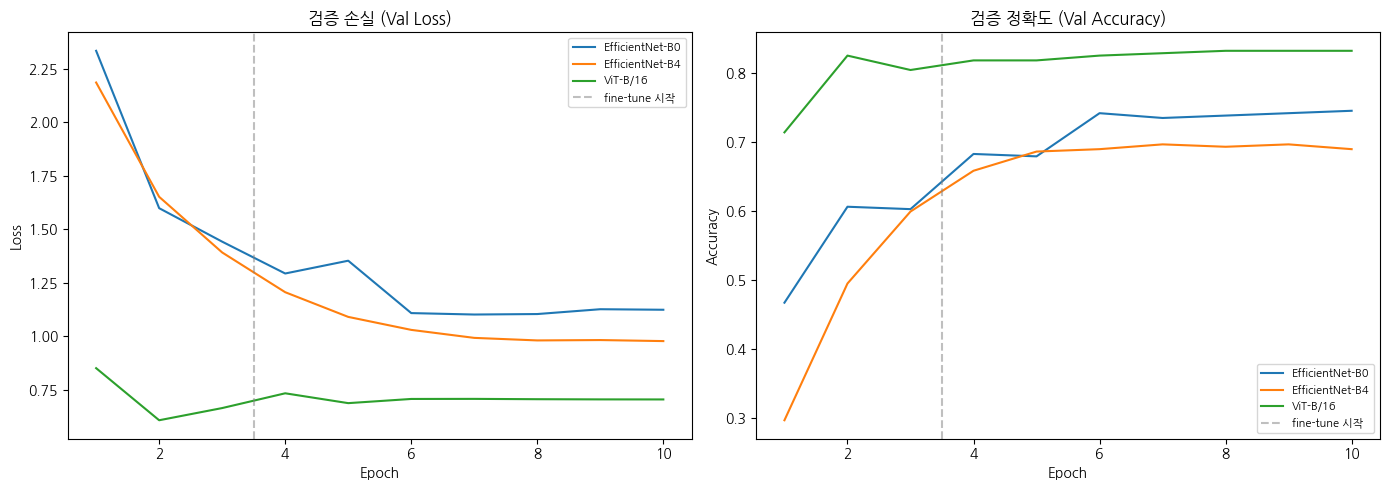

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, grp in results_df.groupby('model'):
    axes[0].plot(grp['epoch'], grp['val_loss'], label=model_name)
    axes[1].plot(grp['epoch'], grp['val_acc'],  label=model_name)

for ax, title, ylabel in zip(
    axes,
    ['검증 손실 (Val Loss)', '검증 정확도 (Val Accuracy)'],
    ['Loss', 'Accuracy'],
):
    ax.axvline(x=PHASE1_EP + 0.5, color='gray', linestyle='--', alpha=0.5, label='fine-tune 시작')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'curves.png', dpi=150)
plt.show()

## 모델 비교 바차트

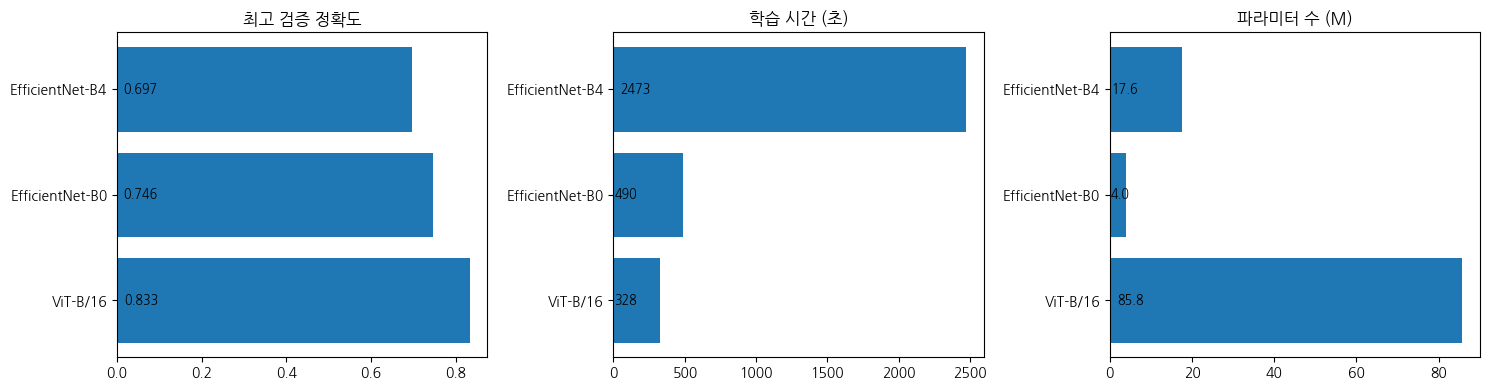

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cols  = ['최고정확도', '학습시간_초', '파라미터_M']
titles = ['최고 검증 정확도', '학습 시간 (초)', '파라미터 수 (M)']
fmts  = ['.3f', '.0f', '.1f']

for ax, col, title, fmt in zip(axes, cols, titles, fmts):
    bars = ax.barh(summary_df['모델'], summary_df[col])
    ax.set_title(title)
    for bar, val in zip(bars, summary_df[col]):
        ax.text(bar.get_width() * 0.02, bar.get_y() + bar.get_height() / 2,
                f'{val:{fmt}}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / 'summary.png', dpi=150)
plt.show()

## 분류 테스트 (검증셋 샘플)

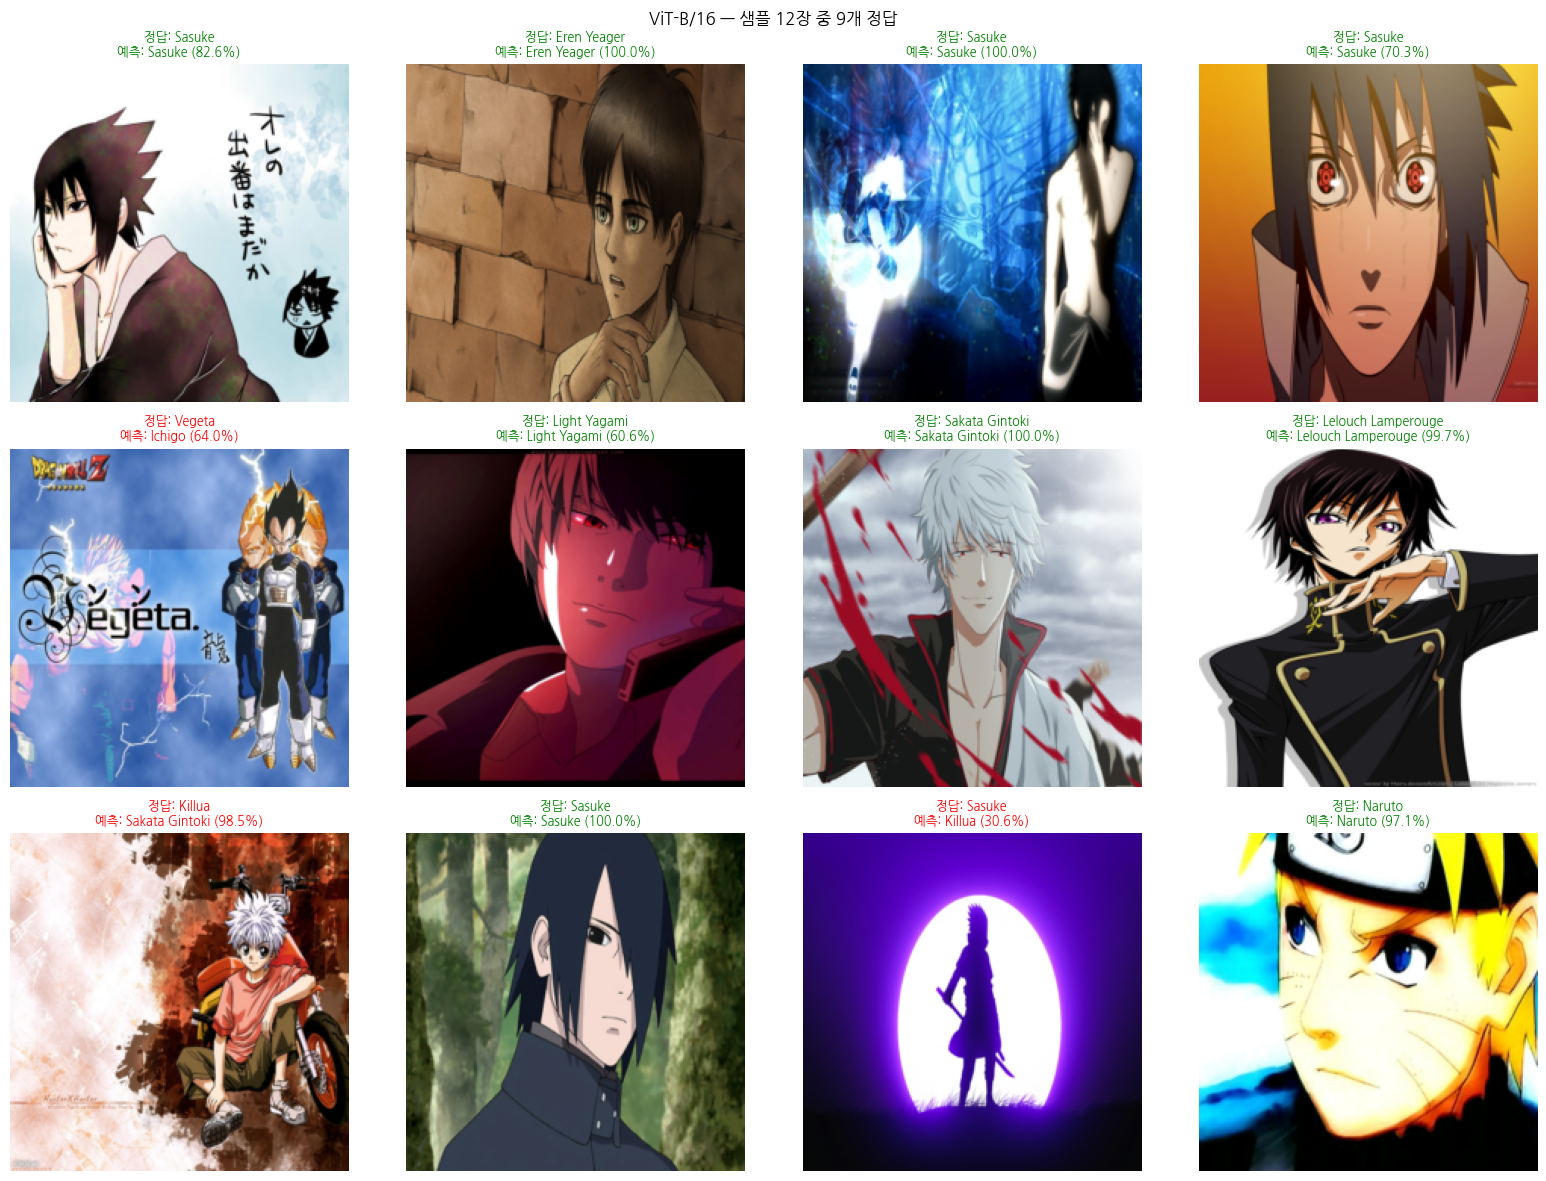

In [10]:
import random
from torchvision import transforms as T

TEST_MODEL  = 'ViT-B/16'   # 테스트할 모델명 (MODELS 중 하나)
N_SAMPLES   = 12            # 표시할 이미지 수
COLS        = 4

# 모델 준비
test_backbone = next(b for n, b in MODELS if n == TEST_MODEL)
test_model = timm.create_model(test_backbone, pretrained=False, num_classes=num_classes).to(device)
test_model.load_state_dict(torch.load(
    OUT_DIR / f'{TEST_MODEL.replace("/", "_")}.pth', map_location=device
))
test_model.eval()

# 검증셋에서 랜덤 샘플
indices = random.sample(range(len(val_ds)), N_SAMPLES)
classes = full_ds.classes

inv_tf = T.Compose([
    T.Normalize(mean=[0, 0, 0], std=[1/0.229, 1/0.224, 1/0.225]),
    T.Normalize(mean=[-0.485, -0.456, -0.406], std=[1, 1, 1]),
])

rows = (N_SAMPLES + COLS - 1) // COLS
fig, axes = plt.subplots(rows, COLS, figsize=(COLS * 4, rows * 4))
axes = axes.flatten()

with torch.no_grad():
    for ax, idx in zip(axes, indices):
        img_tensor, label = val_ds[idx]
        logits = test_model(img_tensor.unsqueeze(0).to(device))
        pred = logits.argmax(1).item()
        prob = logits.softmax(1)[0, pred].item()

        img_show = inv_tf(img_tensor).permute(1, 2, 0).clamp(0, 1).numpy()
        color = 'green' if pred == label else 'red'
        ax.imshow(img_show)
        ax.set_title(
            f'정답: {classes[label].split(" - ")[0]}\n'
            f'예측: {classes[pred].split(" - ")[0]} ({prob:.1%})',
            fontsize=9, color=color
        )
        ax.axis('off')

for ax in axes[N_SAMPLES:]:
    ax.axis('off')

correct = sum(
    test_model(val_ds[i][0].unsqueeze(0).to(device)).argmax(1).item() == val_ds[i][1]
    for i in indices
)
plt.suptitle(f'{TEST_MODEL} — 샘플 {N_SAMPLES}장 중 {correct}개 정답', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / f'test_{TEST_MODEL.replace("/", "_")}.png', dpi=120)
plt.show()